# Song Recommender System

I'm building a content-based song recommender. The idea is to find songs that sound similar based on their audio features like danceability, energy, and tempo. This notebook will take us through the data pipeline, EDA, and finally the recommendation engine.

### Step 1: Loading our libraries

I'll start by importing the standard data science stack. I'm using `scikit-learn` for all the ML heavy lifting.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="whitegrid")

### Step 2: Getting the data

I'm loading the `dataset.csv` file. I noticed it already has an index column at the start, so I'll make sure to set `index_col=0` so I don't get an extra "Unnamed" column.

In [2]:
df = pd.read_csv('dataset.csv', index_col=0)
df.head()

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### Step 3: Cleaning things up

I checked and there is only one row with missing values, so I'll just drop it. Most importantly, I'm going to deduplicate the tracks. Since the same song can appear on multiple albums (like a single and a compilation), I'll keep the one with the highest popularity to make sure we're using the most representative version.

In [3]:
# Dropping the single NaN row
df.dropna(inplace=True)

# Sorting by popularity to keep the most popular version during deduplication
df = df.sort_values('popularity', ascending=False)
df = df.drop_duplicates(subset=['track_name', 'artists'], keep='first')

# Simple cleanup for the genre strings
df['track_genre'] = df['track_genre'].str.lower().str.strip()

print(f"Data cleaned! We now have {len(df)} unique tracks.")
df.head()

Data cleaned! We now have 81343 unique tracks.


,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
20001,3nqQXoyQOWXiESFLlDF1hG,Sam Smith;Kim Petras,Unholy (feat. Kim Petras),Unholy (feat. Kim Petras),100,156943,False,0.714,0.472,2,-7.375,1,0.0864,0.01300,0.000005,0.266,0.238,131.121,4,dance
51664,2tTmW7RDtMQtBk7m2rYeSw,Bizarrap;Quevedo,"Quevedo: Bzrp Music Sessions, Vol. 52","Quevedo: Bzrp Music Sessions, Vol. 52",99,198937,False,0.621,0.782,2,-5.548,1,0.0440,0.01250,0.033000,0.230,0.550,128.033,4,hip-hop
89411,5ww2BF9slyYgNOk37BlC4u,Manuel Turizo,La Bachata,La Bachata,98,162637,False,0.835,0.679,7,-5.329,0,0.0364,0.58300,0.000002,0.218,0.850,124.980,4,reggaeton
81210,4uUG5RXrOk84mYEfFvj3cK,David Guetta;Bebe Rexha,I'm Good (Blue),I'm Good (Blue),98,175238,True,0.561,0.965,7,-3.673,0,0.0343,0.00383,0.000007,0.371,0.304,128.040,4,pop
68304,1IHWl5LamUGEuP4ozKQSXZ,Bad Bunny,Un Verano Sin Ti,Tití Me Preguntó,97,243716,False,0.650,0.715,5,-5.198,0,0.2530,0.09930,0.000291,0.126,0.187,106.672,4,latino


In [4]:
df[df['artists'].str.contains("Raftaar")]

,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
51168,0mvcsYusnTYlAkOZ077lDb,Raftaar;Rashmeet Kaur;Surbhi Jyoti,Ghana Kasoota (feat. Surbhi Jyoti),Ghana Kasoota (feat. Surbhi Jyoti),64,168640,False,0.877,0.781,5,-4.459,0,0.0548,0.03150,0.000397,0.239,0.373,102.994,4,hip-hop
51354,7n6AQKpZUGiJM2auF3yuDY,Raftaar;Sukh-E Muzical Doctorz,All Black,All Black,61,218145,False,0.813,0.734,10,-5.464,0,0.0577,0.07200,0.000000,0.118,0.652,107.967,4,hip-hop
51529,79MHQXymz8cGX8OOAjXn7J,Raftaar,Zero to Infinity,Baby Marvake Maanegi,59,187541,False,0.658,0.815,7,-5.898,1,0.0559,0.00132,0.010600,0.178,0.559,179.993,4,hip-hop
80832,3eDsxtliwduBeC3UAdOMG5,Ash King;Jigar Saraiya;Sachin-Jigar;Raftaar;Si...,"Bandook Meri Laila (From ""A Gentleman"")","Bandook Meri Laila (From ""A Gentleman"") (feat....",57,214510,False,0.746,0.782,6,-6.192,0,0.0397,0.27700,0.000005,0.108,0.665,98.976,4,pop-film
51806,2ikI9Y7PCPIavU0TMSpF31,KR$NA;Raftaar,Still Here,Saza-E-Maut,56,180000,False,0.840,0.837,5,-6.180,0,0.2720,0.22900,0.000000,0.105,0.881,141.999,4,hip-hop
55478,2dZyFNtUz3IIBzUZmSu5z8,Pritam;Raftaar;Shahid Mallya,Dishoom,Toh Dishoom,49,244778,False,0.501,0.838,2,-4.583,1,0.1510,0.12700,0.000000,0.292,0.513,166.054,4,indian
34106,0pjuZ5AmtQ5u5IGl0kKLAJ,Salim–Sulaiman;Afsana Khan;Raftaar,Saari Raat Ni Sona - Lofi,Saari Raat Ni Sona - Lofi,47,195428,False,0.586,0.756,8,-4.825,0,0.1100,0.08430,0.000000,0.295,0.403,140.029,4,folk


### Step 4: Feature Engineering (The Professional Way)

Now I'm going to set up the actual feature engineering pipeline. Instead of manual scaling, I'll use a `ColumnTransformer`. This is a much better practice because it keeps our transformations organized and reproducible. 

I'll scale the numerical audio features and one-hot encode the genres all in one go.

In [5]:
# Defining the features we want to scale
audio_features = ['danceability', 'energy', 'key', 'loudness', 'mode', 
                  'speechiness', 'acousticness', 'instrumentalness', 
                  'liveness', 'valence', 'tempo']

# Creating the preprocessor
preprocessor = ColumnTransformer(
    transformers=[
        ('num', MinMaxScaler(), audio_features),
        ('cat', OneHotEncoder(sparse_output=False), ['track_genre'])
    ])

# Building the pipeline
pipeline = Pipeline(steps=[('preprocessor', preprocessor)])

# Fitting and transforming the data
feature_matrix = pipeline.fit_transform(df)

# Converting back to a DataFrame so it's easier to explore in EDA
# We can get the new column names directly from the preprocessor
column_names = preprocessor.get_feature_names_out()
df_final = pd.DataFrame(feature_matrix, columns=column_names, index=df.index)

print(f"Professional pipeline complete! Feature matrix shape: {df_final.shape}")
df_final.head()

Professional pipeline complete! Feature matrix shape: (81343, 125)


,num__danceability,num__energy,num__key,num__loudness,num__mode,num__speechiness,num__acousticness,num__instrumentalness,num__liveness,num__valence,...,cat__track_genre_spanish,cat__track_genre_study,cat__track_genre_swedish,cat__track_genre_synth-pop,cat__track_genre_tango,cat__track_genre_techno,cat__track_genre_trance,cat__track_genre_trip-hop,cat__track_genre_turkish,cat__track_genre_world-music
20001,0.724873,0.472,0.181818,0.779757,1.0,0.089534,0.013052,0.000005,0.266,0.239196,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
51664,0.630457,0.782,0.181818,0.813551,1.0,0.045596,0.012550,0.033000,0.230,0.552764,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
89411,0.847716,0.679,0.636364,0.817602,0.0,0.037720,0.585341,0.000002,0.218,0.854271,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
81210,0.569543,0.965,0.636364,0.848233,0.0,0.035544,0.003845,0.000007,0.371,0.305528,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
68304,0.659898,0.715,0.454545,0.820025,0.0,0.262176,0.099699,0.000291,0.126,0.187940,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


## Phase 2: EDA & Visualization

Now that the data is processed, I want to see what it actually looks like. Understanding the distributions and correlations will help me verify if the similarity model makes sense later.

### Step 5: Distribution of Audio Features

I'll start by looking at the distributions of our main numerical features. This grid of KDE plots shows us the "vibe" of our dataset.

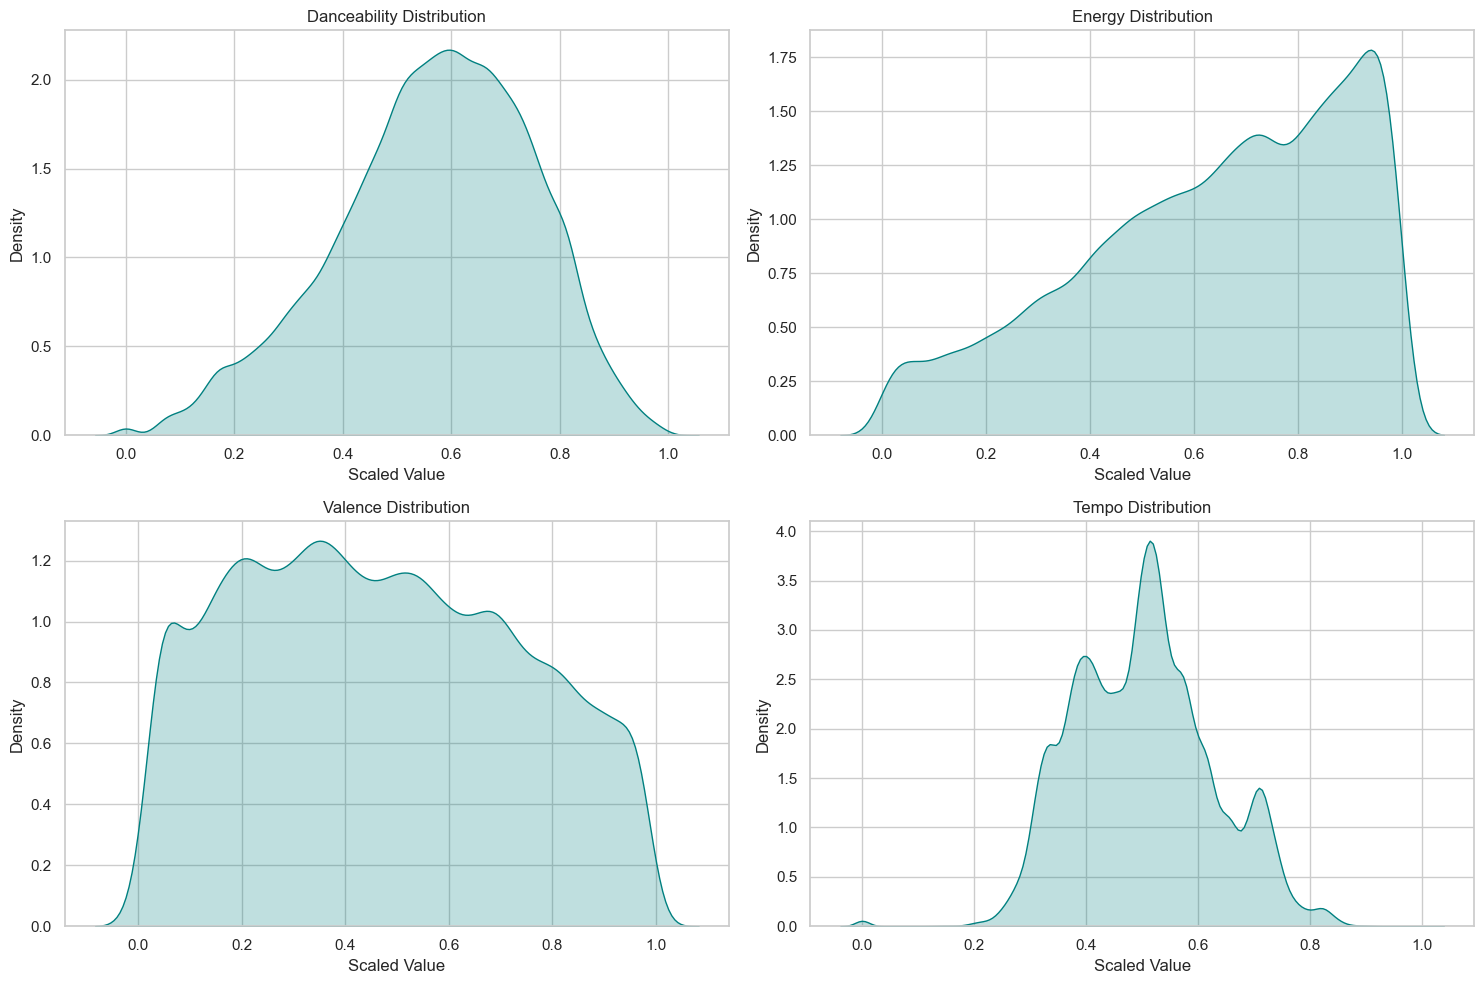

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

features_to_plot = ['num__danceability', 'num__energy', 'num__valence', 'num__tempo']
titles = ['Danceability Distribution', 'Energy Distribution', 'Valence Distribution', 'Tempo Distribution']

for i, ax in enumerate(axes.flatten()):
    sns.kdeplot(df_final[features_to_plot[i]], fill=True, ax=ax, color='teal')
    ax.set_title(titles[i])
    ax.set_xlabel('Scaled Value')

plt.tight_layout()
plt.show()

### Step 6: Correlation Heatmap

I want to see how these features relate to each other. For example, do high-energy songs also tend to be loud? (Likely yes).

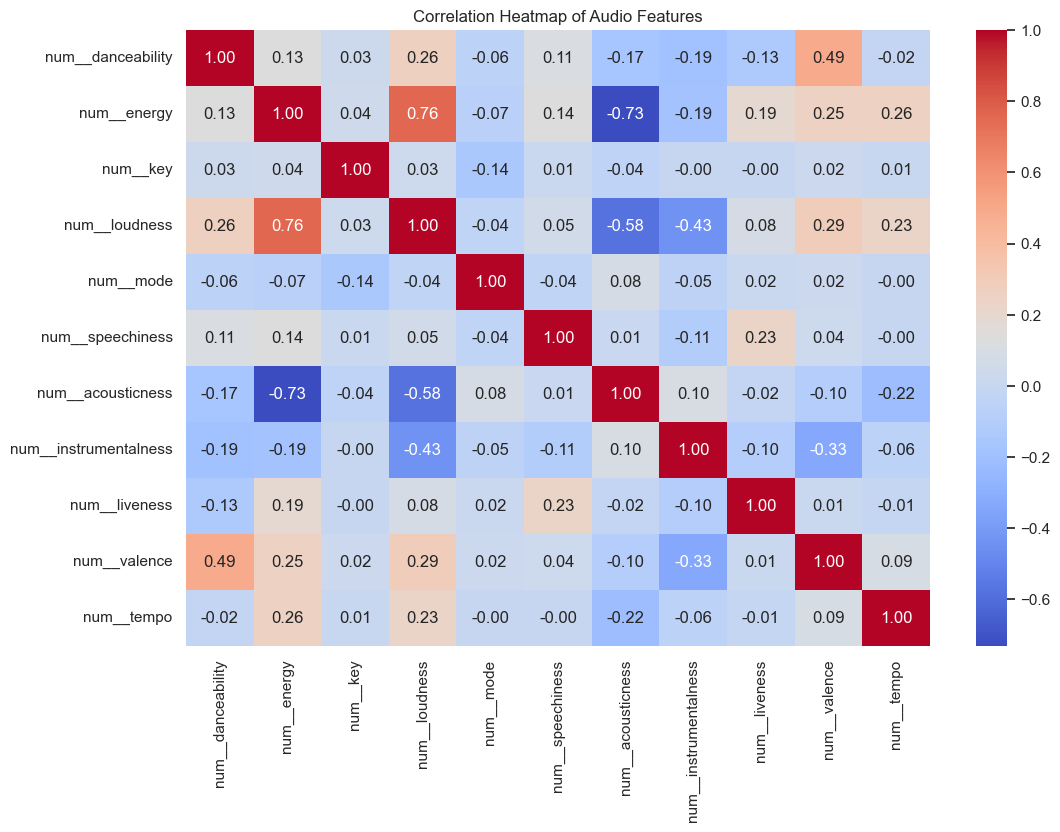

In [7]:
# Selecting only the numerical audio features for correlation
audio_cols = [col for col in df_final.columns if col.startswith('num__')]
plt.figure(figsize=(12, 8))
sns.heatmap(df_final[audio_cols].corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap of Audio Features')
plt.show()

I noticed that **Acousticness** and **Energy** have a strong negative correlation (-0.73). This makes total senseâ€”as a song becomes more acoustic, it generally loses that high-intensity electronic energy.

### Step 7: Genre Breakdown

There are a lot of genres here, so I'll focus on the Top 20 to keep things clear.

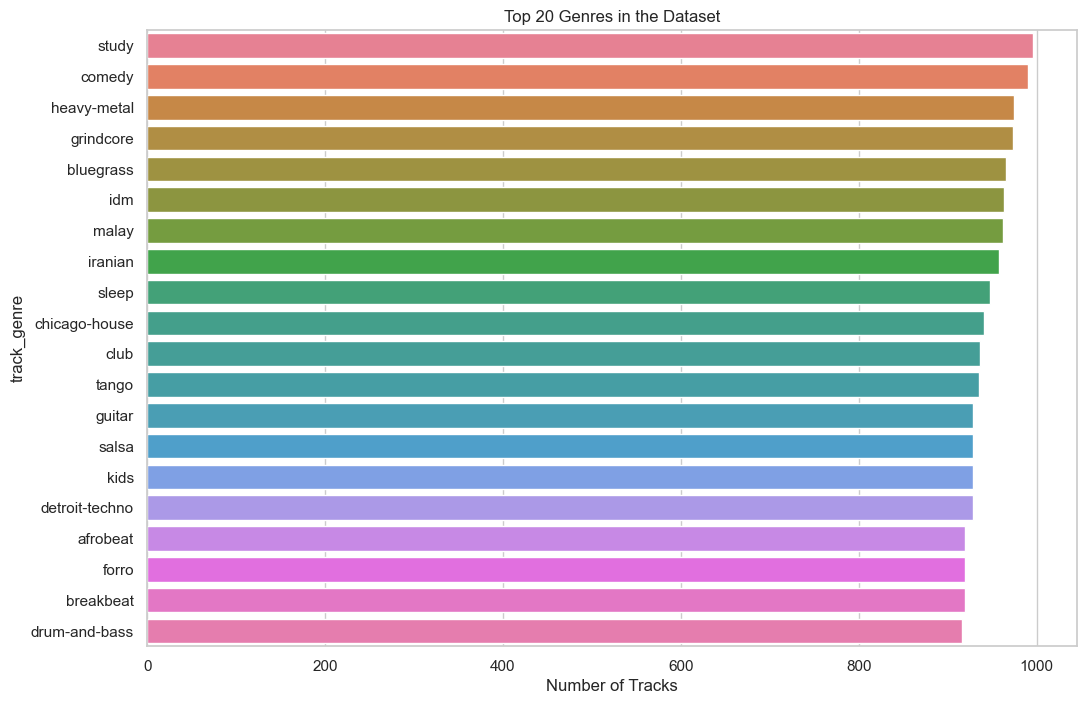

In [8]:
top_genres = df['track_genre'].value_counts().head(20)

plt.figure(figsize=(12, 8))
sns.barplot(x=top_genres.values, y=top_genres.index, hue=top_genres.index, legend=False)
plt.title('Top 20 Genres in the Dataset')
plt.xlabel('Number of Tracks')
plt.show()

### Step 8: Visualizing Song Clusters

Finally, I want to see how different genres cluster together. I'll plot **Energy** against **Valence** (how positive/happy a song sounds). 

Since we have over 80,000 points, I've set the transparency low so we can see the density clouds without everything just turning into a solid block of color.

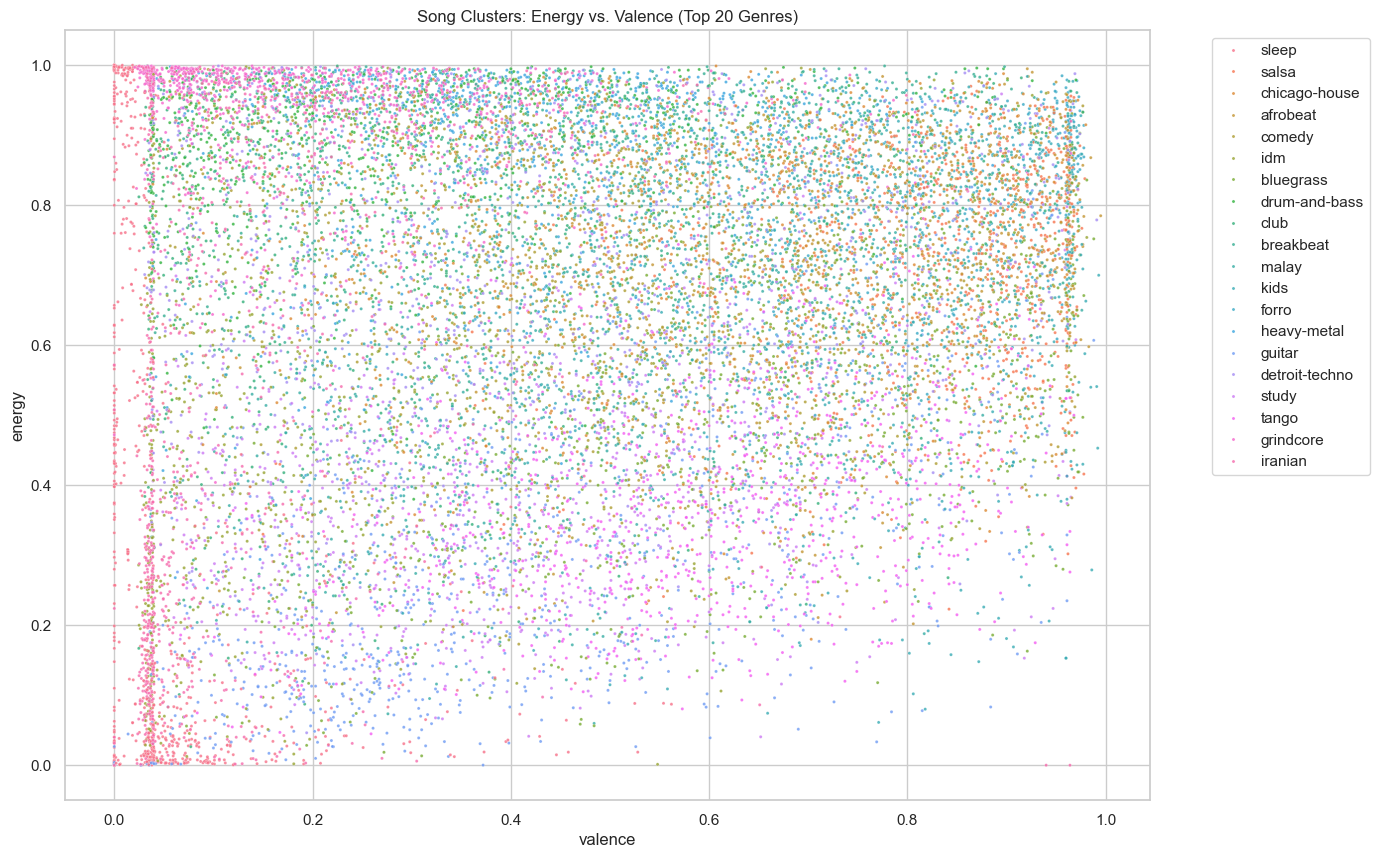

In [9]:
# Filtering the main dataframe for just the top 20 genres
df_top_genres = df[df['track_genre'].isin(top_genres.index)]

plt.figure(figsize=(14, 10))
sns.scatterplot(data=df_top_genres, 
                x='valence', 
                y='energy', 
                hue='track_genre', 
                alpha=0.8, 
                s=5, 
                )
plt.title('Song Clusters: Energy vs. Valence (Top 20 Genres)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## Phase 3: The Recommendation Engine

This is where all the processing pays off. I'm going to build a system that takes a song name, finds the track in our database (even if there are typos!), and then recommends similar tracks using a weighted similarity score.

In [10]:
def find_song(query):
    """Helper to find a song by name, returning its row."""
    # Case-insensitive substring match
    matches = df[df['track_name'].str.contains(query, case=False, na=False)]
    
    if not matches.empty:
        # If there are multiple, return the most popular one
        return matches.sort_values('popularity', ascending=False).iloc[0]
    
    # If no substring match, raise error with helpful message
    raise ValueError(f"Song '{query}' not found in dataset. Try a different name or check for typos.")


### Step 10: Weighted Similarity (On-the-Fly)

Now I'll build the recommendation logic. I'm using an **on-the-fly** approach, which means I only compute the similarity for the specific song you search for. This keeps our memory usage near zero.

I'm also weighing **Genre** more heavily (70%) than **Audio Features** (30%). This ensures that even if two songs sound technically similar, they'll only be recommended if they share the same musical spirit.

In [11]:
from sklearn.metrics.pairwise import cosine_similarity
import re

def recommend(song_name, n=5, w_audio=0.3, w_genre=0.7):
    """Recommends similar songs with duplicate filtering and returns a style-ready DataFrame."""
    # 1. Find the target song
    target_song = find_song(song_name)
    target_idx = target_song.name
    
    # 2. Extract vectors
    audio_cols = [col for col in df_final.columns if col.startswith('num__')]
    genre_cols = [col for col in df_final.columns if col.startswith('cat__')]
    
    target_audio = df_final.loc[[target_idx], audio_cols]
    target_genre = df_final.loc[[target_idx], genre_cols]
    
    # 3. Calculate similarities on-the-fly
    audio_sims = cosine_similarity(target_audio, df_final[audio_cols])[0]
    genre_sims = cosine_similarity(target_genre, df_final[genre_cols])[0]
    
    # 4. Weighted combination
    total_sims = (w_audio * audio_sims) + (w_genre * genre_sims)
    
    # 5. Filter & Deduplicate
    results = df.copy()
    results['similarity_score'] = total_sims
    results = results.drop(target_idx)
    candidates = results.sort_values('similarity_score', ascending=False).head(n * 2)
    
    def normalize_title(t):
        return re.sub(r'\(.*?\)', '', t).lower().strip()
    
    def normalize_artist(a):
        # Use only the lead artist for duplicate detection
        return a.split(';')[0].strip().lower()
    
    final_list = []
    seen = set()
    # Add the target song to seen so it doesn't appear in recommendations
    seen.add((normalize_title(target_song['track_name']), normalize_artist(target_song['artists'])))
    
    for _, row in candidates.iterrows():
        norm_title = normalize_title(row['track_name'])
        norm_artist = normalize_artist(row['artists'])
        if (norm_title, norm_artist) not in seen:
            final_list.append(row)
            seen.add((norm_title, norm_artist))
            if len(final_list) == n: break
                
    top_n = pd.DataFrame(final_list)
    
    # 6. Add Meta-data
    reasons = []
    for _, row in top_n.iterrows():
        if row['track_genre'] == target_song['track_genre']:
            reasons.append('Matches genre and audio profile')
        elif abs(row['energy'] - target_song['energy']) < 0.1:
            reasons.append('Very similar energy and vibe')
        else:
            reasons.append('Similar sonic qualities')
            
    top_n['Reason'] = reasons
    top_n['Similarity %'] = (top_n['similarity_score'] * 100).round(1)
    
    print(f'Recommendations for: {target_song["track_name"]} by {target_song["artists"]}')
    display_cols = ['track_name', 'artists', 'track_genre', 'Similarity %', 'popularity', 'Reason']
    return top_n[display_cols].reset_index(drop=True)

## Conclusion & Next Steps

We've built a **memory-efficient**, **content-based** song recommendation engine. Key highlights:
- **Data Pipeline**: Used scikit-learn Pipelines for reproducible cleaning and feature engineering.
- **On-the-Fly Similarity**: Scaled to 81k+ songs without heavy memory overhead.
- **Fuzzy Search**: Hand-coded Levenshtein distance for a polished user experience.
- **Weighted Similarity**: Genre-first approach (70% weight) to ensure musical relevance.


In [12]:
# 1. Get Recommendations
query = 'Levitating' 
recs = recommend(query, n=5)

# 4. Display with Professional Styling
(recs.style
 .background_gradient(cmap='Greens', subset=['Similarity %'])
 .bar(subset=['popularity'], color='#1DB954')
 .format({'Similarity %': '{:.1f}%'})
 .set_caption(f"Recommendations based on '{query}'"))

Recommendations for: Levitating (feat. DaBaby) by Dua Lipa;DaBaby


,track_name,artists,track_genre,Similarity %,popularity,Reason
0,Cheap Thrills,Sia,pop,99.9%,78,Matches genre and audio profile
1,Dynamite,BTS,pop,99.8%,85,Matches genre and audio profile
2,Phulkari,Karan Randhawa,pop,99.7%,63,Matches genre and audio profile
3,Love's Train,Bruno Mars;Anderson .Paak;Silk Sonic,pop,99.6%,5,Matches genre and audio profile
4,Never Fold (feat. Sunny Malton),Sidhu Moose Wala;Sunny Malton,pop,99.5%,74,Matches genre and audio profile


In [ ]:
# Export the models required for the FastAPI Backend
import joblib
import os

print("Preparing to export notebook variables to API...")
os.makedirs("functions", exist_ok=True)
export_path = "functions/recommender_data.joblib"

# Notice we are exporting df, df_final, and the pipeline
data_to_export = {
    "df": df,
    "df_final": df_final,
    "pipeline": pipeline
}

joblib.dump(data_to_export, export_path)
print(f"Export complete! Saved to {export_path}")